# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves. Thanks [Yandex Data School Analysis](https://github.com/yandexdataschool/Practical_DL/blob/fall21/week03_convnets/seminar_pytorch.ipynb) for this work!

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

![image](https://github.com/yandexdataschool/Practical_DL/raw/fall21/week03_convnets/cifar10.jpg)

In [1]:
# when running in colab, un-comment this
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall19/week03_convnets/cifar.py

--2026-04-24 11:04:22--  https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall19/week03_convnets/cifar.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2396 (2.3K) [text/plain]
Saving to: ‘cifar.py’

cifar.py            100%[===================>]   2.34K  --.-KB/s    in 0.001s  

2026-04-24 11:04:23 (4.47 MB/s) - ‘cifar.py’ saved [2396/2396]



In [2]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

Dataset not found. Downloading...
(40000, 3, 32, 32) (40000,)


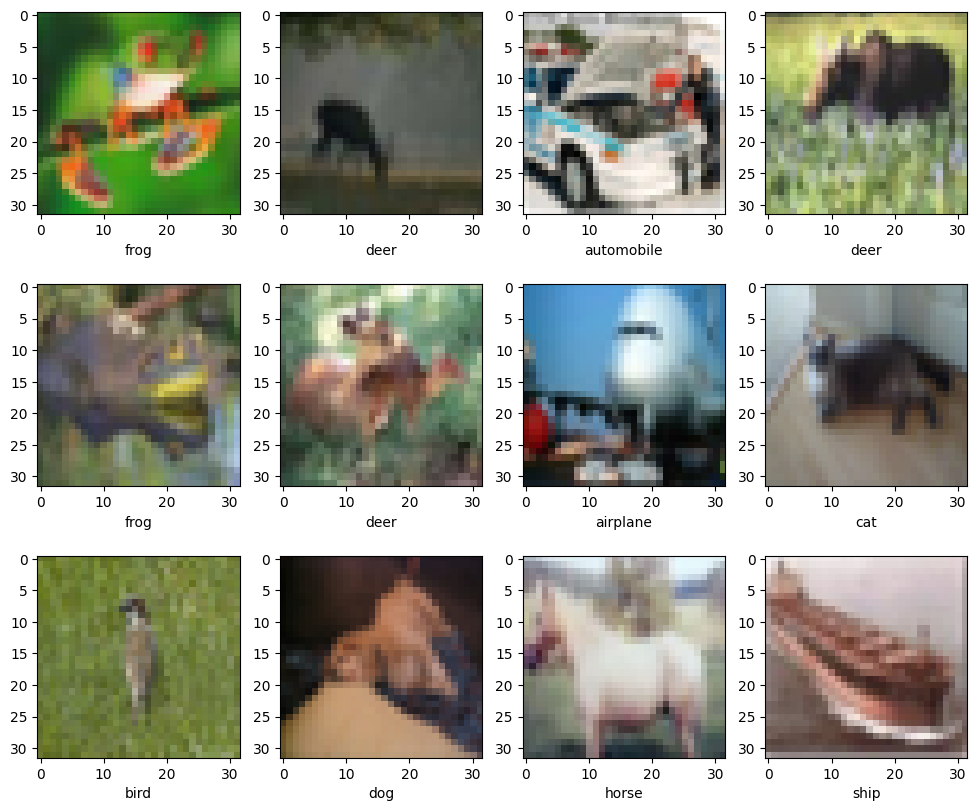

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

In [4]:
import torch, torch.nn as nn
import torch.nn.functional as F

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

Let's start with a dense network for our baseline:

In [5]:
model = nn.Sequential()

# reshape from "images" to flat vectors
model.add_module('flatten', Flatten())

# dense "head"
model.add_module('dense1', nn.Linear(3 * 32 * 32, 64))
model.add_module('dense1_relu', nn.ReLU())
model.add_module('dense2_logits', nn.Linear(64, 10)) # logits for 10 classes

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [6]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [7]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.2983, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [8]:
# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [9]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

In [10]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 2.373s
  training loss (in-iteration): 	2.027040
  validation accuracy: 			34.53 %
Epoch 2 of 100 took 1.252s
  training loss (in-iteration): 	1.853528
  validation accuracy: 			36.29 %
Epoch 3 of 100 took 0.892s
  training loss (in-iteration): 	1.788400
  validation accuracy: 			38.26 %
Epoch 4 of 100 took 0.676s
  training loss (in-iteration): 	1.740542
  validation accuracy: 			40.55 %
Epoch 5 of 100 took 0.913s
  training loss (in-iteration): 	1.699645
  validation accuracy: 			41.34 %
Epoch 6 of 100 took 0.813s
  training loss (in-iteration): 	1.665337
  validation accuracy: 			42.28 %
Epoch 7 of 100 took 0.827s
  training loss (in-iteration): 	1.636554
  validation accuracy: 			43.09 %
Epoch 8 of 100 took 0.800s
  training loss (in-iteration): 	1.609290
  validation accuracy: 			44.53 %
Epoch 9 of 100 took 0.794s
  training loss (in-iteration): 	1.588836
  validation accuracy: 			44.74 %
Epoch 10 of 100 took 0.820s
  training loss (in-iteration): 	1.567815
  v

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [11]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		48.57 %
We need more magic! Follow instructons below


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [12]:
# model
model = nn.Sequential()

# conv block
model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

# classifier
model.add_module('flatten', Flatten())
model.add_module('dense1', nn.Linear(10 * 15 * 15, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.1))
model.add_module('dense2_logits', nn.Linear(100, 10))

# optimizer
opt = torch.optim.Adam(model.parameters())

# history
train_loss = []
val_accuracy = []

# training
num_epochs = 100
batch_size = 50

for epoch in range(num_epochs):
    start_time = time.time()

    # training pass
    model.train(True)
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())

    # validation pass
    model.train(False)
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))

    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size:])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size:]) * 100))

# final test
model.train(False)
test_batch_acc = []

for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Epoch 1 of 100 took 1.800s
  training loss (in-iteration): 	1.663137
  validation accuracy: 			48.14 %
Epoch 2 of 100 took 2.106s
  training loss (in-iteration): 	1.374040
  validation accuracy: 			53.14 %
Epoch 3 of 100 took 1.916s
  training loss (in-iteration): 	1.277468
  validation accuracy: 			55.17 %
Epoch 4 of 100 took 1.859s
  training loss (in-iteration): 	1.212162
  validation accuracy: 			56.70 %
Epoch 5 of 100 took 1.861s
  training loss (in-iteration): 	1.157498
  validation accuracy: 			58.75 %
Epoch 6 of 100 took 1.818s
  training loss (in-iteration): 	1.113481
  validation accuracy: 			58.70 %
Epoch 7 of 100 took 1.812s
  training loss (in-iteration): 	1.068435
  validation accuracy: 			59.58 %
Epoch 8 of 100 took 1.868s
  training loss (in-iteration): 	1.026987
  validation accuracy: 			58.84 %
Epoch 9 of 100 took 2.218s
  training loss (in-iteration): 	0.987800
  validation accuracy: 			59.12 %
Epoch 10 of 100 took 1.872s
  training loss (in-iteration): 	0.954245
  v

```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [13]:
# model with batch normalization
model = nn.Sequential()

# conv block
model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('bn1', nn.BatchNorm2d(10))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

# classifier
model.add_module('flatten', Flatten())
model.add_module('dense1', nn.Linear(10 * 15 * 15, 100))
model.add_module('bn2', nn.BatchNorm1d(100))
model.add_module('relu2', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.1))
model.add_module('dense2_logits', nn.Linear(100, 10))

# optimizer
opt = torch.optim.Adam(model.parameters())

# history
train_loss = []
val_accuracy = []

# training
num_epochs = 100
batch_size = 50

for epoch in range(num_epochs):
    start_time = time.time()

    # training
    model.train(True)
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())

    # validation
    model.train(False)
    batch_accs = []
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        batch_accs.append(np.mean(y_batch == y_pred))
        val_accuracy.append(np.mean(y_batch == y_pred))

    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-max(1, len(X_train) // batch_size):])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(batch_accs) * 100))

# final test
model.train(False)
test_batch_acc = []

for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Epoch 1 of 100 took 2.493s
  training loss (in-iteration): 	1.394204
  validation accuracy: 			56.01 %
Epoch 2 of 100 took 2.523s
  training loss (in-iteration): 	1.105621
  validation accuracy: 			57.75 %
Epoch 3 of 100 took 2.438s
  training loss (in-iteration): 	0.974439
  validation accuracy: 			60.80 %
Epoch 4 of 100 took 2.446s
  training loss (in-iteration): 	0.878478
  validation accuracy: 			64.84 %
Epoch 5 of 100 took 2.460s
  training loss (in-iteration): 	0.806426
  validation accuracy: 			60.16 %
Epoch 6 of 100 took 2.517s
  training loss (in-iteration): 	0.740117
  validation accuracy: 			60.76 %
Epoch 7 of 100 took 2.488s
  training loss (in-iteration): 	0.684911
  validation accuracy: 			65.09 %
Epoch 8 of 100 took 2.597s
  training loss (in-iteration): 	0.636778
  validation accuracy: 			58.27 %
Epoch 9 of 100 took 2.517s
  training loss (in-iteration): 	0.586039
  validation accuracy: 			60.73 %
Epoch 10 of 100 took 2.563s
  training loss (in-iteration): 	0.549700
  v


```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [14]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [15]:
from torchvision.datasets import CIFAR10
train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)

train_batch_gen = torch.utils.data.DataLoader(train_loader,
                                              batch_size=32,
                                              shuffle=True,
                                              num_workers=1)

X: <class 'torch.Tensor'> torch.Size([32, 3, 32, 32])
y: <class 'torch.Tensor'> torch.Size([32])


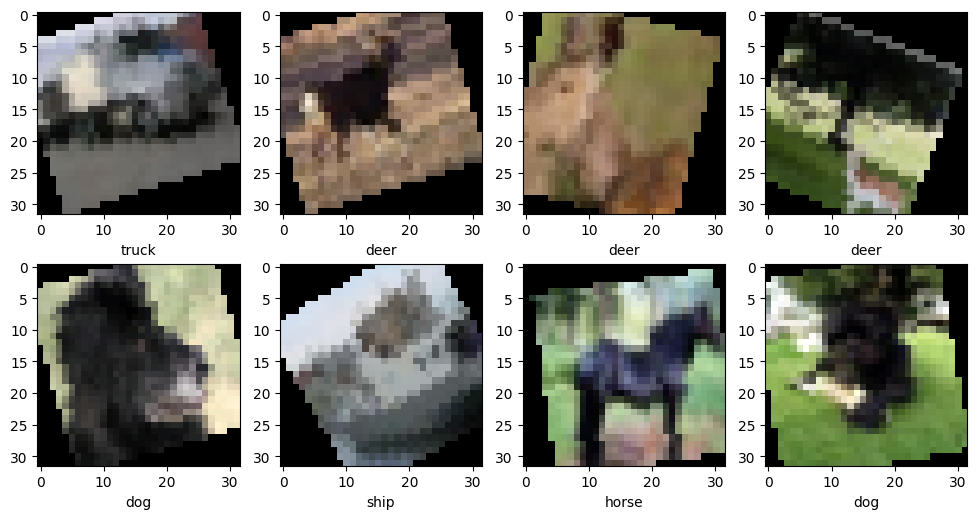

In [17]:
# quick visual sanity check on one augmented batch
x_batch, y_batch = next(iter(train_batch_gen))
print('X:', type(x_batch), x_batch.shape)
print('y:', type(y_batch), y_batch.shape)

plt.figure(figsize=[12, 6])
for i, img in enumerate(x_batch.numpy()[:8]):
    plt.subplot(2, 4, i + 1)
    plt.xlabel(class_names[int(y_batch[i])])
    # denormalize back to [0, 1] for display
    plt.imshow(np.clip(img.transpose([1, 2, 0]) * stds + means, 0, 1))
plt.show()

When testing, we don't need random crops, just normalize with same statistics.

In [18]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

# test dataset — same normalization as train, no random crops/flips
test_loader = CIFAR10("./cifar_data/", train=False, download=True, transform=transform_test)

test_batch_gen = torch.utils.data.DataLoader(
    test_loader,
    batch_size=32,
    shuffle=False,
    num_workers=1,
)

In [19]:
from torchvision import transforms
from torchvision.datasets import CIFAR10

# normalization stats
means = np.array((0.4914, 0.4822, 0.4465))
stds = np.array((0.2023, 0.1994, 0.2010))

# train-time augmentation
transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

# test-time preprocessing
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

# datasets
train_loader = CIFAR10("./cifar_data/", train=True, download=True, transform=transform_augment)
test_loader = CIFAR10("./cifar_data/", train=False, download=True, transform=transform_test)

# dataloaders
train_batch_gen = torch.utils.data.DataLoader(
    train_loader,
    batch_size=32,
    shuffle=True,
    num_workers=1
)

test_batch_gen = torch.utils.data.DataLoader(
    test_loader,
    batch_size=32,
    shuffle=False,
    num_workers=1
)

# model
model = nn.Sequential()

model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('bn1', nn.BatchNorm2d(10))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

model.add_module('flatten', Flatten())
model.add_module('dense1', nn.Linear(10 * 15 * 15, 100))
model.add_module('bn2', nn.BatchNorm1d(100))
model.add_module('relu2', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.1))
model.add_module('dense2_logits', nn.Linear(100, 10))

# loss
def compute_loss(X_batch, y_batch):
    if not torch.is_tensor(X_batch):
        X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    else:
        X_batch = X_batch.float()

    if not torch.is_tensor(y_batch):
        y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    else:
        y_batch = y_batch.long()

    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

# optimizer
opt = torch.optim.Adam(model.parameters())

# history
train_loss = []
test_accuracy = []

# training
num_epochs = 20

for epoch in range(num_epochs):
    start_time = time.time()

    # training
    model.train(True)
    epoch_losses = []

    for X_batch, y_batch in train_batch_gen:
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()

        epoch_losses.append(loss.item())
        train_loss.append(loss.item())

    # evaluation
    model.train(False)
    batch_accs = []

    with torch.no_grad():
        for X_batch, y_batch in test_batch_gen:
            logits = model(X_batch.float())
            y_pred = logits.max(1)[1]
            batch_accs.append((y_pred == y_batch).float().mean().item())

    epoch_test_acc = np.mean(batch_accs)
    test_accuracy.append(epoch_test_acc)

    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss:\t\t{:.6f}".format(np.mean(epoch_losses)))
    print("  test accuracy:\t\t{:.2f} %".format(epoch_test_acc * 100))

# final test
model.train(False)
test_batch_acc = []

with torch.no_grad():
    for X_batch, y_batch in test_batch_gen:
        logits = model(X_batch.float())
        y_pred = logits.max(1)[1]
        test_batch_acc.append((y_pred == y_batch).float().mean().item())

final_test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(final_test_accuracy * 100))

if final_test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif final_test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif final_test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif final_test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif final_test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif final_test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Epoch 1 of 20 took 13.515s
  training loss:		1.663651
  test accuracy:		50.87 %
Epoch 2 of 20 took 14.335s
  training loss:		1.514067
  test accuracy:		53.48 %
Epoch 3 of 20 took 14.164s
  training loss:		1.467182
  test accuracy:		55.00 %
Epoch 4 of 20 took 14.149s
  training loss:		1.439188
  test accuracy:		55.14 %
Epoch 5 of 20 took 13.803s
  training loss:		1.417478
  test accuracy:		56.31 %
Epoch 6 of 20 took 14.225s
  training loss:		1.398653
  test accuracy:		59.27 %
Epoch 7 of 20 took 14.001s
  training loss:		1.377596
  test accuracy:		58.06 %
Epoch 8 of 20 took 14.308s
  training loss:		1.368715
  test accuracy:		59.85 %
Epoch 9 of 20 took 14.618s
  training loss:		1.358478
  test accuracy:		59.55 %
Epoch 10 of 20 took 13.925s
  training loss:		1.343981
  test accuracy:		60.74 %
Epoch 11 of 20 took 13.943s
  training loss:		1.336691
  test accuracy:		60.85 %
Epoch 12 of 20 took 14.925s
  training loss:		1.323796
  test accuracy:		61.59 %
Epoch 13 of 20 took 14.843s
  trainin

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [ ]:
import time
from copy import deepcopy

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

means = (0.4914, 0.4822, 0.4465)
stds  = (0.2023, 0.1994, 0.2010)

def to_chw_float_tensor(x):
    x = torch.as_tensor(x, dtype=torch.float32)
    # support both CHW and HWC just in case
    if x.ndim == 3 and x.shape[0] != 3 and x.shape[-1] == 3:
        x = x.permute(2, 0, 1)
    # support uint8-like scales if they appear
    if x.max() > 1.5:
        x = x / 255.0
    return x

class ArrayDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = to_chw_float_tensor(self.X[idx])
        y = int(self.y[idx])

        if self.transform is not None:
            x = self.transform(x)

        return x, y

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Normalize(means, stds),
])

transform_eval = transforms.Compose([
    transforms.Normalize(means, stds),
])

train_ds = ArrayDataset(X_train, y_train, transform=transform_train)
val_ds   = ArrayDataset(X_val,   y_val,   transform=transform_eval)
test_ds  = ArrayDataset(X_test,  y_test,  transform=transform_eval)

batch_size = 128

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

class BetterNet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BetterNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

def run_epoch(loader, train=True):
    if train:
        model.train(True)
    else:
        model.train(False)

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total_count += X_batch.size(0)

    return total_loss / total_count, total_correct / total_count

num_epochs = 40
early_stopping_patience = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0
best_epoch = -1
best_state = None
bad_epochs = 0

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  lr:               {:.6f}".format(current_lr))
    print("  train loss:       {:.6f}".format(train_loss))
    print("  train accuracy:   {:.2f} %".format(train_acc * 100))
    print("  val loss:         {:.6f}".format(val_loss))
    print("  val accuracy:     {:.2f} %".format(val_acc * 100))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_state = deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= early_stopping_patience:
        print("Early stopping!")
        break

# restore best model by validation accuracy
model.load_state_dict(best_state)

# final test
test_loss, test_acc = run_epoch(test_loader, train=False)

print("\nFinal results:")
print("  best epoch:       {}".format(best_epoch))
print("  best val acc:     {:.2f} %".format(best_val_acc * 100))
print("  test loss:        {:.6f}".format(test_loss))
print("  test accuracy:    {:.2f} %".format(test_acc * 100))

if test_acc * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_acc * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_acc * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_acc * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_acc * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_acc * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

device: cuda
Epoch 1 of 40 took 13.231s
  lr:               0.000300
  train loss:       1.609789
  train accuracy:   40.46 %
  val loss:         1.347431
  val accuracy:     49.32 %
Epoch 2 of 40 took 12.299s
  lr:               0.000300
  train loss:       1.271564
  train accuracy:   53.97 %
  val loss:         1.075881
  val accuracy:     61.18 %
Epoch 3 of 40 took 12.323s
  lr:               0.000300
  train loss:       1.119326
  train accuracy:   59.90 %
  val loss:         1.009662
  val accuracy:     63.19 %
Epoch 4 of 40 took 12.270s
  lr:               0.000300
  train loss:       1.037579
  train accuracy:   63.02 %
  val loss:         0.931057
  val accuracy:     66.97 %
Epoch 5 of 40 took 11.908s
  lr:               0.000300
  train loss:       0.970441
  train accuracy:   65.65 %
  val loss:         0.871530
  val accuracy:     69.63 %
Epoch 6 of 40 took 11.829s
  lr:               0.000300
  train loss:       0.907260
  train accuracy:   68.07 %
  val loss:         0.80

: 